In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("cleaned_ecommerce_data_sample.csv")

In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,555200,71459,HANGING JAM JAR T-LIGHT HOLDER,24,06-01-2011 12:05,0.85,17315.0,United Kingdom
1,554974,21128,GOLD FISHING GNOME,4,5/27/2011 17:14,6.95,14031.0,United Kingdom
2,550972,21086,SET/6 RED SPOTTY PAPER CUPS,4,4/21/2011 17:05,0.65,14031.0,United Kingdom
3,576652,22812,PACK 3 BOXES CHRISTMAS PANETTONE,3,11/16/2011 10:39,1.95,17198.0,United Kingdom
4,546157,22180,RETROSPOT LAMP,2,03-10-2011 08:40,9.95,13502.0,United Kingdom


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   InvoiceNo    50000 non-null  object 
 1   StockCode    50000 non-null  object 
 2   Description  49860 non-null  object 
 3   Quantity     50000 non-null  int64  
 4   InvoiceDate  50000 non-null  object 
 5   UnitPrice    50000 non-null  float64
 6   CustomerID   37396 non-null  float64
 7   Country      50000 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 3.1+ MB


In [5]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,50000.000000,50000.000000,37396.000000
mean,10.773740,4.775116,15275.486977
std,334.688375,92.048367,1713.881652
min,-2472.000000,0.000000,12346.000000
25%,1.000000,1.250000,13949.000000
50%,3.000000,2.080000,15110.000000
75%,10.000000,4.130000,16782.000000
max,74215.000000,13541.330000,18287.000000


In [6]:
df.isnull().sum()

InvoiceNo          0
StockCode          0
Description      140
Quantity           0
InvoiceDate        0
UnitPrice          0
CustomerID     12604
Country            0
dtype: int64

In [7]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

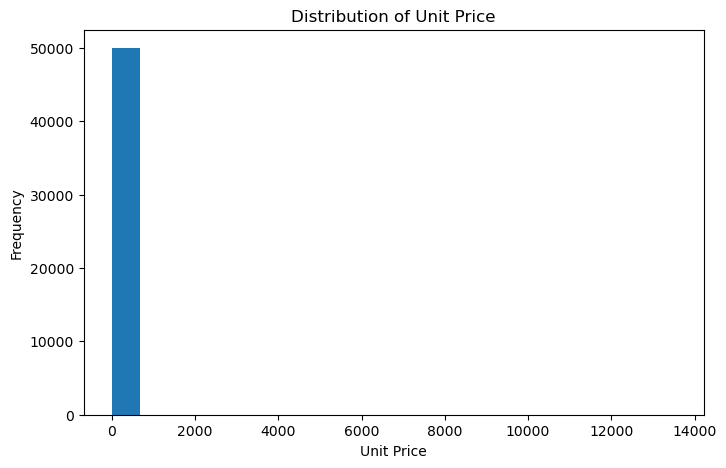

In [8]:
plt.figure(figsize=(8,5))
plt.hist(df["UnitPrice"], bins=20)
plt.title("Distribution of Unit Price")
plt.xlabel("Unit Price")
plt.ylabel("Frequency")
plt.show()

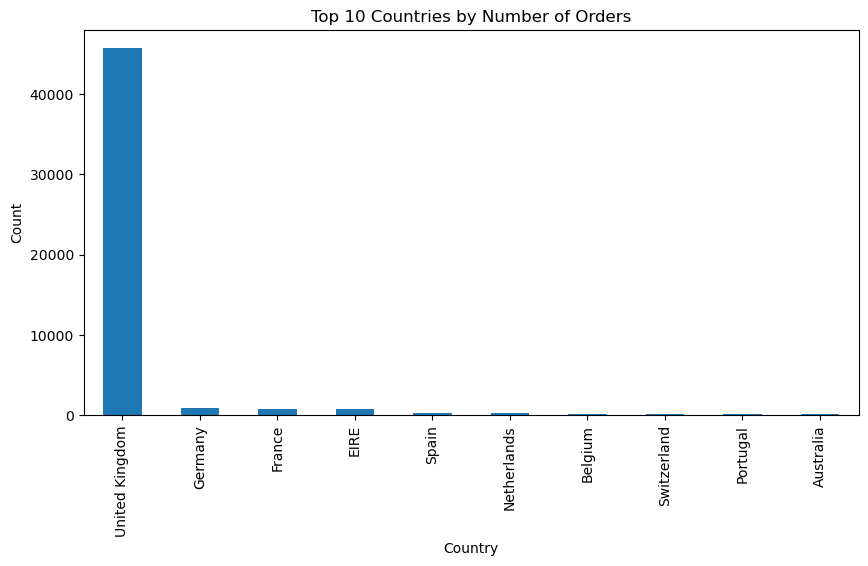

In [9]:
top_countries = df["Country"].value_counts().head(10)

plt.figure(figsize=(10,5))
top_countries.plot(kind="bar")
plt.title("Top 10 Countries by Number of Orders")
plt.xlabel("Country")
plt.ylabel("Count")
plt.show()

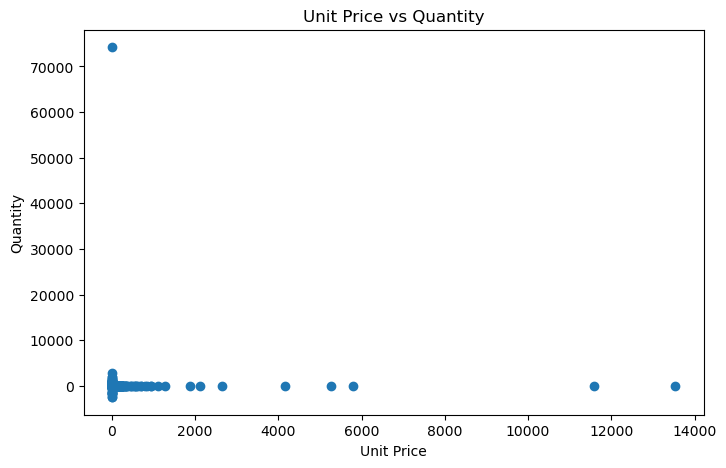

In [10]:
plt.figure(figsize=(8,5))
plt.scatter(df["UnitPrice"], df["Quantity"])
plt.title("Unit Price vs Quantity")
plt.xlabel("Unit Price")
plt.ylabel("Quantity")
plt.show()

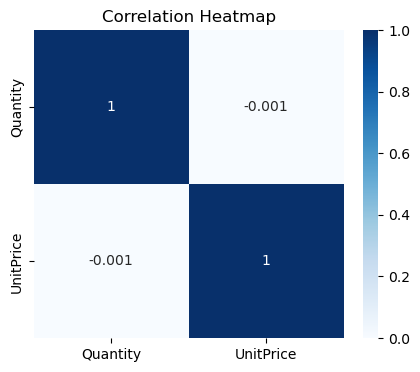

In [11]:
corr = df[["Quantity", "UnitPrice"]].corr()

plt.figure(figsize=(5,4))
sns.heatmap(corr, annot=True, cmap="Blues")
plt.title("Correlation Heatmap")
plt.show()

In [12]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

In [13]:
df["Revenue"].sum()

np.float64(970447.7609999999)

In [14]:
top_products = df.groupby("Description")["Revenue"].sum().sort_values(ascending=False).head(10)

print(top_products)

Description
MEDIUM CERAMIC TOP STORAGE JAR        77521.14
DOTCOM POSTAGE                        18271.92
REGENCY CAKESTAND 3 TIER              13304.18
GIN + TONIC DIET METAL SIGN            9432.06
JUMBO BAG RED RETROSPOT                8614.17
PARTY BUNTING                          8321.75
CHILLI LIGHTS                          6816.36
POSTAGE                                6111.46
WHITE HANGING HEART T-LIGHT HOLDER     5926.68
RABBIT NIGHT LIGHT                     4597.89
Name: Revenue, dtype: float64


In [15]:
country_revenue = df.groupby("Country")["Revenue"].sum().sort_values(ascending=False)

print(country_revenue)

Country
United Kingdom          830308.081
Netherlands              24969.800
EIRE                     24034.980
France                   22007.630
Germany                  20008.980
Australia                11805.010
Spain                     5328.220
Switzerland               5047.130
Hong Kong                 3570.650
Belgium                   3307.210
Norway                    2976.200
Portugal                  2937.700
Japan                     2230.380
Finland                   1661.220
Channel Islands           1638.200
Italy                     1561.840
Sweden                    1350.410
Denmark                   1262.700
Cyprus                    1108.220
Austria                   1040.570
Poland                     622.080
Israel                     528.530
Iceland                    412.600
Unspecified                349.190
Greece                     344.140
USA                        274.570
Bahrain                    225.000
United Arab Emirates       215.520
Canada      

In [1]:
df.to_csv("cleaned_ecommerce_data_sample_updated.csv", index=False)

NameError: name 'df' is not defined

In [2]:
import pandas as pd

df = pd.read_csv("cleaned_ecommerce_data_sample.csv")

In [3]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

In [4]:
df.to_csv("cleaned_ecommerce_data_sample_updated.csv", index=False)

In [1]:
df.to_csv("cleaned_ecommerce_data_sample_updated.csv", index=False)
print("Saved!")

NameError: name 'df' is not defined

In [2]:
import pandas as pd
import sqlite3

# Step 1: Reload data
df = pd.read_csv("cleaned_ecommerce_data_sample.csv")

# Step 2: Create Revenue column
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

# Step 3: Save updated CSV
df.to_csv("cleaned_ecommerce_data_sample_updated.csv", index=False)
print("✅ CSV Saved!")

# Step 4: Setup SQLite
conn = sqlite3.connect(':memory:')
df.to_sql('ecommerce', conn, index=False)
print("✅ Database ready!")

# Step 5: Show columns
print(df.columns.tolist())

✅ CSV Saved!
✅ Database ready!
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'Revenue']


In [3]:
q1 = pd.read_sql("""
    SELECT Country, ROUND(SUM(Revenue), 2) as Total_Revenue
    FROM ecommerce
    GROUP BY Country
    ORDER BY Total_Revenue DESC
    LIMIT 5
""", conn)
print("Top 5 Countries by Revenue:")
print(q1)

Top 5 Countries by Revenue:
          Country  Total_Revenue
0  United Kingdom      830308.08
1     Netherlands       24969.80
2            EIRE       24034.98
3          France       22007.63
4         Germany       20008.98


In [4]:
q2 = pd.read_sql("""
    SELECT substr(InvoiceDate, 1, 7) as Month,
           ROUND(SUM(Revenue), 2) as Monthly_Revenue
    FROM ecommerce
    GROUP BY Month
    ORDER BY Month
""", conn)
print("Monthly Sales Trend:")
print(q2)

Monthly Sales Trend:
       Month  Monthly_Revenue
0    01-04-2          1162.20
1    01-05-2          4591.94
2    01-06-2          4357.19
3    01-07-2          3086.04
4    01-09-2          1183.33
..       ...              ...
293  9/26/20          3490.39
294  9/27/20          3572.76
295  9/28/20          3686.14
296  9/29/20          4643.77
297  9/30/20          3523.51

[298 rows x 2 columns]


In [5]:
q3 = pd.read_sql("""
    SELECT CustomerID, ROUND(SUM(Revenue), 2) as Total_Spent
    FROM ecommerce
    GROUP BY CustomerID
    ORDER BY Total_Spent DESC
    LIMIT 5
""", conn)
print("Top 5 Customers:")
print(q3)

Top 5 Customers:
   CustomerID  Total_Spent
0         NaN    141294.27
1     12346.0     77183.60
2     18102.0     27688.32
3     14646.0     24549.79
4     17450.0     15135.12


In [6]:
q4 = pd.read_sql("""
    SELECT Description, ROUND(SUM(Revenue), 2) as Total_Revenue
    FROM ecommerce
    GROUP BY Description
    ORDER BY Total_Revenue DESC
    LIMIT 5
""", conn)
print("Top 5 Products:")
print(q4)

Top 5 Products:
                      Description  Total_Revenue
0  MEDIUM CERAMIC TOP STORAGE JAR       77521.14
1                  DOTCOM POSTAGE       18271.92
2        REGENCY CAKESTAND 3 TIER       13304.18
3     GIN + TONIC DIET METAL SIGN        9432.06
4         JUMBO BAG RED RETROSPOT        8614.17


In [7]:
q5 = pd.read_sql("""
    SELECT Country, ROUND(AVG(Revenue), 2) as Avg_Order_Value
    FROM ecommerce
    GROUP BY Country
    ORDER BY Avg_Order_Value DESC
    LIMIT 5
""", conn)
print("Avg Order Value by Country:")
print(q5)

Avg Order Value by Country:
       Country  Avg_Order_Value
0    Hong Kong           127.52
1  Netherlands           117.78
2    Australia           105.40
3        Japan            79.66
4      Bahrain            45.00


In [8]:
print("Total Revenue:", round(df['Revenue'].sum(), 2))
print("Total Orders:", df['InvoiceNo'].nunique())
print("Total Customers:", df['CustomerID'].nunique())
print("Top Country:", df.groupby('Country')['Revenue'].sum().idxmax())

Total Revenue: 970447.76
Total Orders: 14401
Total Customers: 3775
Top Country: United Kingdom


In [1]:
pd.read_csv("../data/SampleSuperstore.csv")

NameError: name 'pd' is not defined

In [2]:
df = pd.read_csv("../data/Sample - Superstore.csv")

NameError: name 'pd' is not defined

In [3]:
df = pd.read_csv(r"C:\apexplanet\data\Sample - Superstore.csv")

NameError: name 'pd' is not defined

In [4]:
import os

print(os.listdir("../data"))

FileNotFoundError: [WinError 3] The system cannot find the path specified: '../data'

In [5]:
import pandas as pd
import sqlite3

df = pd.read_csv("../data/Sample - Superstore.csv", encoding="latin1")

conn = sqlite3.connect("superstore.db")

df.to_sql("sales", conn, if_exists="replace", index=False)

print("Data Imported Successfully")

FileNotFoundError: [Errno 2] No such file or directory: '../data/Sample - Superstore.csv'

In [6]:
df = pd.read_csv("../data/Sample - Superstore.csv", encoding="cp1252")

FileNotFoundError: [Errno 2] No such file or directory: '../data/Sample - Superstore.csv'

In [7]:
df = pd.read_csv("../data/Sample - Superstore.csv", encoding="latin1")
print(df.head())
print(df.columns)

FileNotFoundError: [Errno 2] No such file or directory: '../data/Sample - Superstore.csv'

In [8]:
query = "SELECT * FROM sales LIMIT 5"

pd.read_sql(query, conn)

NameError: name 'conn' is not defined

In [9]:
import sqlite3

conn = sqlite3.connect("superstore.db")

In [10]:
import sqlite3
import pandas as pd

df = pd.read_csv("Sample - Superstore.csv")

conn = sqlite3.connect(":memory:")
df.to_sql("sales", conn, index=False, if_exists="replace")

FileNotFoundError: [Errno 2] No such file or directory: 'Sample - Superstore.csv'

In [11]:
import os
print(os.getcwd())

C:\Users\S LAXMI VYSHNAVI


In [12]:
import os
print(os.listdir())

['.anaconda', '.conda', '.continuum', '.ipynb_checkpoints', '.ipython', '.jupyter', '.matplotlib', 'anaconda3', 'apex', 'AppData', 'Application Data', 'cleaned_ecommerce_data.csv', 'cleaned_ecommerce_data_sample.csv', 'cleaned_ecommerce_data_sample_updated.csv', 'Contacts', 'Cookies', 'Documents', 'Downloads', 'Links', 'Local Settings', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{16d1218f-9986-11f0-b65f-502e91689701}.TM.blf', 'NTUSER.DAT{16d1218f-9986-11f0-b65f-502e91689701}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{16d1218f-9986-11f0-b65f-502e91689701}.TMContainer00000000000000000002.regtrans-ms', 'ntuser.ini', 'OneDrive', 'PrintHood', 'Recent', 'Saved Games', 'Searches', 'SendTo', 'Start Menu', 'superstore.db', 'Task1_Data_Cleaning.ipynb', 'Task2_EDA.ipynb', 'Templates', 'Untitled.ipynb', 'Untitled1.ipynb', 'Videos']


In [13]:
import pandas as pd

df = pd.read_csv(r"C:\Users\S LAXMI VYSHNAVI\Downloads\Sample - Superstore.csv")
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\S LAXMI VYSHNAVI\\Downloads\\Sample - Superstore.csv'

In [14]:
import os

print(os.path.exists(r"C:\Users\S LAXMI VYSHNAVI\Downloads\Sample - Superstore.csv"))
print(os.listdir(r"C:\Users\S LAXMI VYSHNAVI\Downloads"))

False
['.ipynb_checkpoints', 'Anaconda3-2025.12-2-Windows-x86_64.exe', 'archive (1).zip', 'archive.zip', 'desktop.ini', 'ecommerce_data.csv', 'mysql-installer-web-community-8.0.46.0.msi', 'python-manager-26.2.msix', 'Task1_Data_Cleaning.ipynb']


In [15]:
path=r"

SyntaxError: unterminated string literal (detected at line 1) (2230252925.py, line 1)

In [16]:
"C:\Users\S LAXMI VYSHNAVI\Downloads\archive (1)\Sample - Superstore.csv"

SyntaxError: (unicode error) 'unicodeescape' codec can't decode bytes in position 2-3: truncated \UXXXXXXXX escape (2300422510.py, line 1)

In [17]:
import pandas as pd

df = pd.read_csv(r"C:\Users\S LAXMI VYSHNAVI\Downloads\archive (1)\Sample - Superstore.csv")

df.head()

UnicodeDecodeError: 'utf-8' codec can't decode byte 0xa0 in position 2944: invalid start byte

In [18]:
import os

print(os.path.isfile(r"C:\Users\S LAXMI VYSHNAVI\Downloads\archive (1)\Sample - Superstore.csv"))

True


In [19]:
import pandas as pd

df = pd.read_csv(
    r"C:\Users\S LAXMI VYSHNAVI\Downloads\archive (1)\Sample - Superstore.csv",
    encoding="latin1"
)

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [20]:
df.shape

(9994, 21)

In [21]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [23]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [24]:
import sqlite3

conn = sqlite3.connect(":memory:")
df.to_sql("sales", conn, if_exists="replace", index=False)

9994

In [25]:
query = "SELECT * FROM sales LIMIT 5"
pd.read_sql(query, conn)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [26]:
query = "SELECT SUM(Sales) AS Total_Sales FROM sales"
pd.read_sql(query, conn)

,Total_Sales
0,2.297201e+06


In [27]:
query = """
SELECT `Product Name`, SUM(Sales) AS Total_Sales
FROM sales
GROUP BY `Product Name`
ORDER BY Total_Sales DESC
LIMIT 5;
"""
pd.read_sql(query, conn)

,Product Name,Total_Sales
0,Canon imageCLASS 2200 Advanced Copier,61599.824
1,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.384
2,Cisco TelePresence System EX90 Videoconferenci...,22638.480
3,HON 5400 Series Task Chairs for Big and Tall,21870.576
4,GBC DocuBind TL300 Electric Binding System,19823.479


In [28]:
query = """
SELECT Region, SUM(Sales) AS Total_Sales
FROM sales
GROUP BY Region;
"""
pd.read_sql(query, conn)

,Region,Total_Sales
0,Central,501239.8908
1,East,678781.2400
2,South,391721.9050
3,West,725457.8245


In [29]:
query = """
SELECT Category, SUM(Profit) AS Total_Profit
FROM sales
GROUP BY Category;
"""
pd.read_sql(query, conn)

,Category,Total_Profit
0,Furniture,18451.2728
1,Office Supplies,122490.8008
2,Technology,145454.9481


In [30]:
query = """
SELECT Category, SUM(Profit) AS Total_Profit
FROM sales
GROUP BY Category;
"""
pd.read_sql(query, conn)

,Category,Total_Profit
0,Furniture,18451.2728
1,Office Supplies,122490.8008
2,Technology,145454.9481


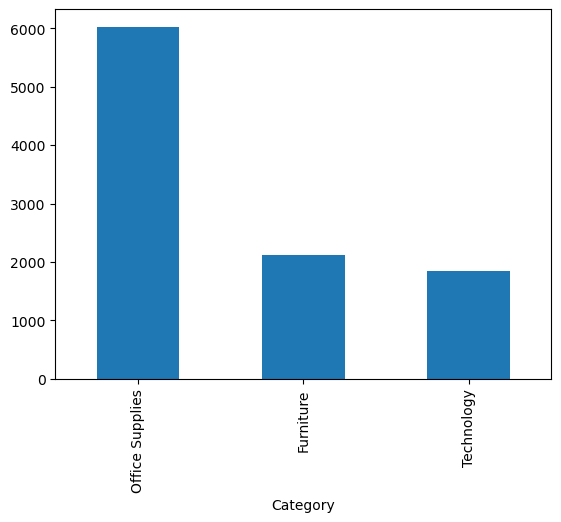

In [31]:
import matplotlib.pyplot as plt

df["Category"].value_counts().plot(kind="bar")
plt.show()

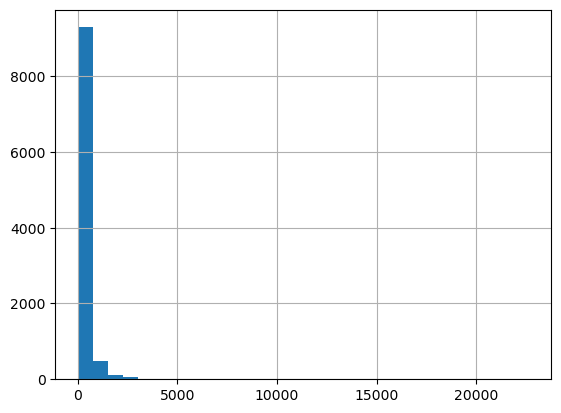

In [32]:
df["Sales"].hist(bins=30)
plt.show()

In [33]:
df.corr(numeric_only=True)

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
Row ID,1.000000,0.009671,-0.001359,-0.004016,0.013480,0.012497
Postal Code,0.009671,1.000000,-0.023854,0.012761,0.058443,-0.029961
Sales,-0.001359,-0.023854,1.000000,0.200795,-0.028190,0.479064
Quantity,-0.004016,0.012761,0.200795,1.000000,0.008623,0.066253
Discount,0.013480,0.058443,-0.028190,0.008623,1.000000,-0.219487
Profit,0.012497,-0.029961,0.479064,0.066253,-0.219487,1.000000


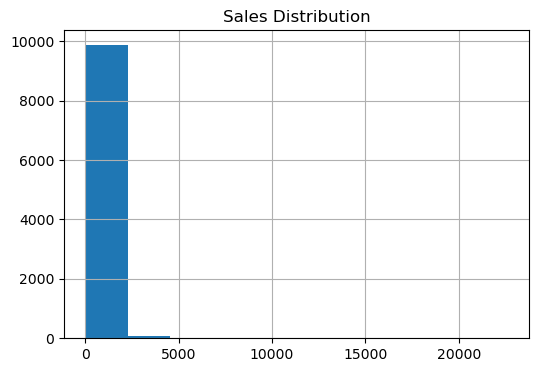

In [34]:
import matplotlib.pyplot as plt

df["Sales"].hist(figsize=(6,4))
plt.title("Sales Distribution")
plt.show()

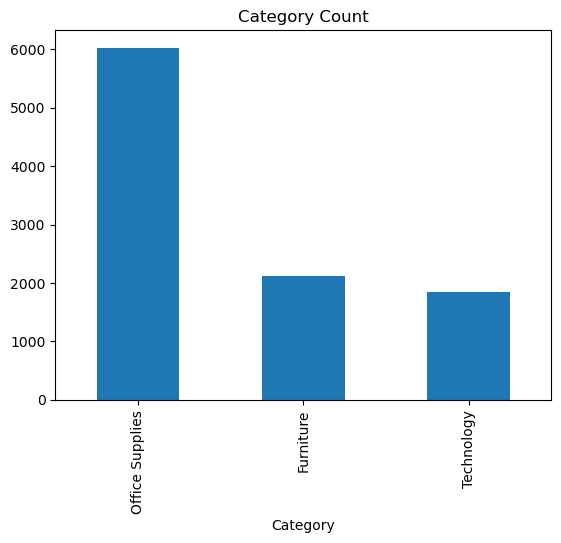

In [35]:
df["Category"].value_counts().plot(kind="bar")
plt.title("Category Count")
plt.show()

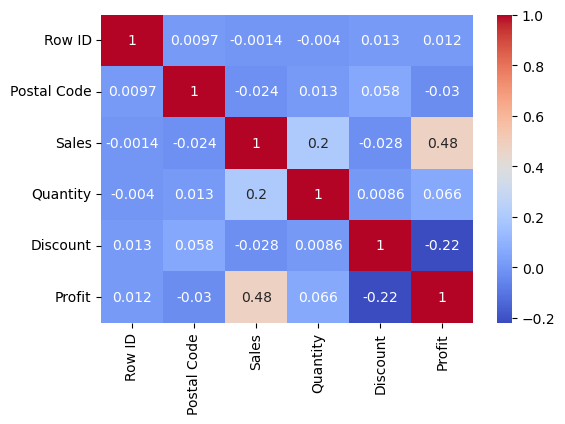

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

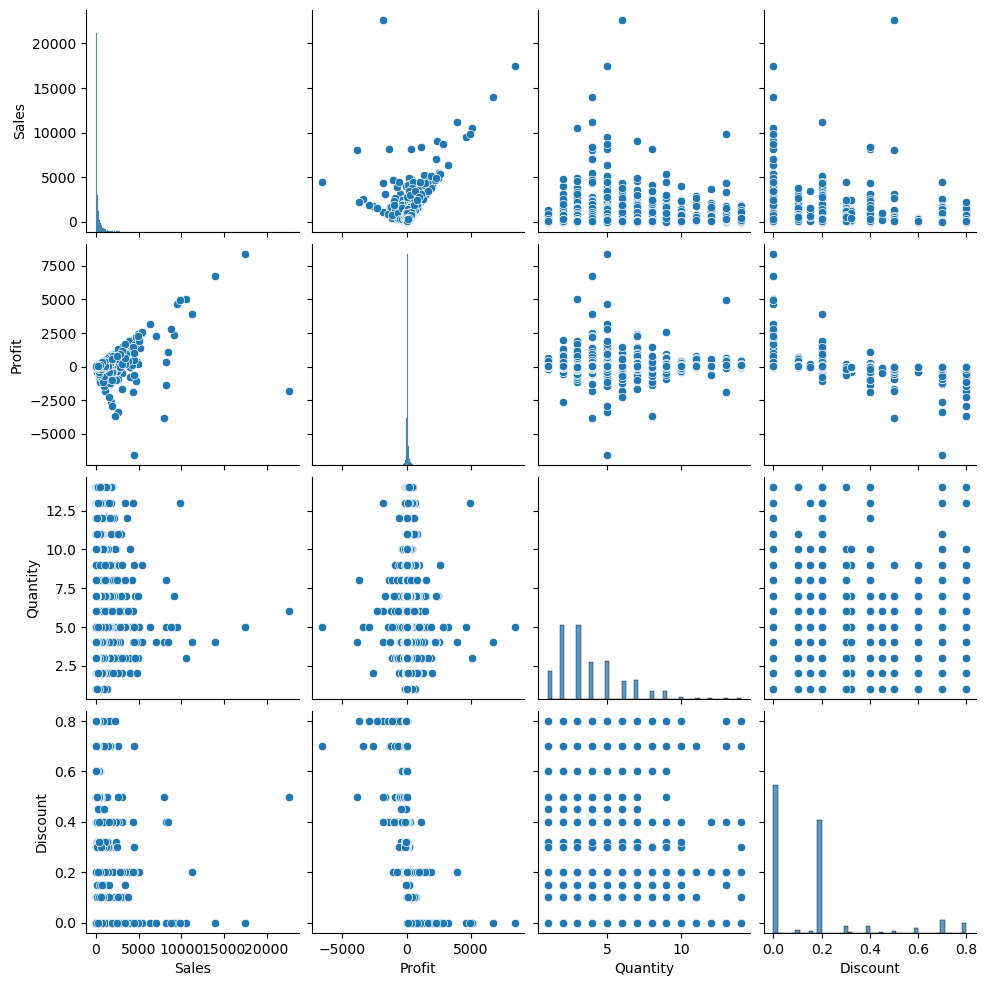

In [37]:
sns.pairplot(df[["Sales","Profit","Quantity","Discount"]])
plt.show()